
# Gantry Polling Speed Test — OEM-2T Controller Read-Only ACP Polling

**What this measures.** The fastest reliable rate at which position feedback
(`ACP` — actual/stepper position) can be polled from the Modusystems OEM-2T
rev D motion controller over the lab's existing link, at its current,
unmodified serial configuration (9600 baud, 8N1).

**Why it matters.** Any experiment that wants to log gantry position
alongside other instruments (flow, weir, gauge, cameras) needs to know how
fast that polling can realistically go before commands start timing out or
responses start arriving corrupted/overlapping. This notebook answers that
question empirically, on the real hardware, rather than assuming a rate.

## Topology

```
this machine --SSH--> oak@red.dyn.ucr.edu (Pi, "oak" account)
                            |
                       serial_bridge.py (raw TCP<->serial passthrough, port 9700)
                            |
                       RS232 (9600 8N1) --> OEM-2T rev D controller --> gantry motors
```

The controller sits physically too far from the PC for direct serial, so a
Raspberry Pi next to it runs `serial_bridge.py` — a small, protocol-unaware
TCP-to-serial passthrough (not a systemd service; started manually, see
`docs/MACRON_GANTRY.md`). The PC side connects with a **direct TCP socket to
`red.dyn.ucr.edu:9700`** — this is a separate connection from the SSH session
used only to check/start the bridge process; polling traffic does not
traverse SSH at all.

## Protocol (verified against `src/laguna/robot/macron/connection.py`)

- Commands are ASCII, CR-terminated (`"A1 ACP\r"`).
- Responses terminate at a literal `>` prompt character — not CRLF.
- Success envelope: `"0 <value> >"` (e.g. `"0 0.005 >"`).
- Error envelope: `"<escape_code> >"` — note the absent leading `"0"`. The
  only reliable way to tell success from error is checking whether the
  first token equals the literal string `"0"`, never by numeric magnitude.

## Axis mapping (per `docs/MACRON_GANTRY.md`)

| Axis | Firmware index | Command | Node |
|---|---|---|---|
| X | 1 | `A1 ACP` | commander (local controller) |
| Y | 2 | `A2 ACP` | commander |
| Z | 5 | `A5 ACP` | responder (2nd networked PLC node) |
| Theta | 6 | `A6 ACP` | responder |

## Safety constraint

This entire test suite **only ever sends these four exact read-only status
queries**: `A1 ACP`, `A2 ACP`, `A5 ACP`, `A6 ACP`. No motion, jog, move, or
configuration command was ever constructed or sent — see
`benchmark_polling.py`'s `ALLOWED_COMMANDS` assertion, checked immediately
before every write. The axes were not expected to move, and did not; this
is purely a read-only feedback-polling benchmark. The controller's/bridge's
baud rate was left at its existing configured value (9600 8N1) throughout —
the goal was to measure the real-world ceiling of the *current*
configuration, not to reconfigure the hardware.

## Method: what `benchmark_polling.py` actually did

For each target frequency in **1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024
Hz** (powers of two), the script ran a stage that repeatedly executed one
"cycle" = querying all 4 axes in sequence (`A1 ACP`, `A2 ACP`, `A5 ACP`,
`A6 ACP`), once per target period (`1/target_hz` seconds between cycle
starts), for a stage duration of `max(15, min(60, 30/target_hz))` seconds —
at least 15 s so even fast stages get a solid sample, scaled up for very low
frequencies so 1-2 Hz stages still collect on the order of 30 cycles, capped
at 60 s so the sweep stays practical. For this specific frequency sequence
that works out to 30 s at 1 Hz and 15 s at every frequency from 2 Hz up
(30/2 already floors to the 15 s minimum) — about 3 minutes of total runtime.

**Read timeout.** Before the sweep, 160 warm-up queries (40 back-to-back
4-axis cycles, no pacing delay) characterized baseline round-trip latency:
median ≈ 79 ms, p95 ≈ 81 ms, max ≈ 82 ms over that sample (responder-node
axes Z/Theta consistently slower than commander-node axes X/Y, since the
commander has to bridge internally to the second PLC node). The per-query
read timeout was set to **0.5 s** — roughly 6x the observed p95/max, long
enough that a genuinely-slow-but-real response isn't misclassified as a
timeout, short enough that a single stuck read can never stall the whole
benchmark for long (even a worst-case all-4-axes-timeout cycle only costs
2 s, trivial against a 15-60 s stage budget).

**Response classification**, applied to every individual axis query:
- **success** — a terminating `>` arrived and the payload parsed as `"0
  <value>"` with `<value>` a valid float.
- **timeout** — no terminating `>` arrived within the 0.5 s read window.
- **parse_error** — a `>` arrived (framing looked intact) but the payload
  didn't parse as a success value — either a genuine firmware error
  envelope (`"<code> >"`, first token != `"0"`) or a `"0 ..."` envelope
  whose value token wasn't a parseable number.
- **garbled** — the classic signature of a dropped/overlapping response at
  an unsustainable poll rate: more than one `>` in a single read (a
  leftover fragment from a late-arriving previous response got
  concatenated with the next one), or the payload didn't even tokenize
  into a plausible 1-2-token numeric envelope.

The script deliberately does **not** clear the serial input buffer before
each query, so that this kind of overlap/garbling — if the link is pushed
past what it can sustain — is observable in the data rather than silently
erased.

**"Kept pace"**, per cycle: a cycle is marked as having kept pace with its
target rate if its actual wall-clock duration was no more than **1.5x** the
intended target period. This tolerance absorbs ordinary scheduling/GC
jitter without flagging every marginal cycle as a miss, while still clearly
surfacing the frequencies where the link structurally cannot keep up.

Raw, per-poll results are in `data/raw_polls.csv` (every single query, all
stages). Per-frequency rollups are in `data/summary_by_frequency.csv`. Both
are loaded below.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.width", 120)

raw = pd.read_csv("data/raw_polls.csv")
summary = pd.read_csv("data/summary_by_frequency.csv")

# Fixed categorical colors, in fixed order (X, Y, Z, Theta) -- never
# reassigned/cycled based on filtering, per the axis order used throughout
# this project's docs. Chosen from a validated colorblind-safe categorical
# palette (blue/green/orange/violet slots), avoiding the lower-contrast
# magenta/yellow/aqua slots on a light chart surface.
AXIS_COLORS = {
    "X": "#2a78d6",      # blue
    "Y": "#008300",      # green
    "Z": "#eb6834",      # orange
    "Theta": "#4a3aa7",  # violet
}
AXIS_ORDER = ["X", "Y", "Z", "Theta"]

raw.head()


,target_hz,cycle_index,axis,command,t_send_perf,t_send_epoch,t_recv_perf,t_recv_epoch,latency_s,raw_bytes_repr,raw_len,classification,parsed_value,error_code,cycle_target_period_s,cycle_actual_duration_s,kept_pace
0,1,0,X,A1 ACP,187080.882807,1.784342e+09,187080.943757,1.784342e+09,0.060951,b'0 0.005 >',9,success,0.005,NaN,1.0,0.286075,True
1,1,0,Y,A2 ACP,187080.943847,1.784342e+09,187081.008636,1.784342e+09,0.064789,b'0 0.005 >',9,success,0.005,NaN,1.0,0.286075,True
2,1,0,Z,A5 ACP,187081.008722,1.784342e+09,187081.087654,1.784342e+09,0.078932,b'0 0.005 >',9,success,0.005,NaN,1.0,0.286075,True
3,1,0,Theta,A6 ACP,187081.087691,1.784342e+09,187081.168797,1.784342e+09,0.081106,b'0 0.025 >',9,success,0.025,NaN,1.0,0.286075,True
4,1,1,X,A1 ACP,187081.882978,1.784342e+09,187081.926185,1.784342e+09,0.043207,b'0 0.005 >',9,success,0.005,NaN,1.0,0.259965,True


In [2]:

summary


,target_hz,target_period_s,stage_duration_requested_s,stage_duration_actual_s,cycles_attempted,cycles_fully_successful,cycles_kept_pace,total_axis_polls,successful_axis_polls,timeout_count,...,p95_latency_Y_s,max_latency_Y_s,mean_latency_Z_s,median_latency_Z_s,p95_latency_Z_s,max_latency_Z_s,mean_latency_Theta_s,median_latency_Theta_s,p95_latency_Theta_s,max_latency_Theta_s
0,1,1.000000,30.0,30.000170,30,30,30,120,120,0,...,0.057763,0.064789,0.079653,0.079811,0.080945,0.081075,0.080067,0.079976,0.081115,0.081279
1,2,0.500000,15.0,15.000084,30,30,30,120,120,0,...,0.057597,0.057871,0.079942,0.079881,0.081137,0.081546,0.079888,0.079920,0.080988,0.081827
2,4,0.250000,15.0,15.202265,53,53,53,212,212,0,...,0.064905,0.065747,0.079847,0.079908,0.080963,0.081065,0.079805,0.079869,0.080943,0.080996
3,8,0.125000,15.0,15.242634,53,53,0,212,212,0,...,0.064920,0.065011,0.079873,0.079905,0.081054,0.082010,0.079825,0.079862,0.080994,0.081049
4,16,0.062500,15.0,15.241722,53,53,0,212,212,0,...,0.064960,0.065098,0.079754,0.079798,0.081073,0.081695,0.079907,0.079867,0.080978,0.081113
5,32,0.031250,15.0,15.241514,53,53,0,212,212,0,...,0.064923,0.065992,0.079894,0.079919,0.080990,0.081056,0.079714,0.079828,0.080923,0.081151
6,64,0.015625,15.0,15.243183,53,53,0,212,212,0,...,0.064980,0.066760,0.079794,0.079924,0.081067,0.081125,0.079835,0.079804,0.080982,0.081832
7,128,0.007812,15.0,15.240537,53,53,0,212,212,0,...,0.064892,0.064993,0.079882,0.079841,0.081112,0.081894,0.079824,0.079876,0.080980,0.081131
8,256,0.003906,15.0,15.242368,53,53,0,212,212,0,...,0.064872,0.065085,0.079901,0.079921,0.081034,0.082035,0.079867,0.079915,0.080955,0.083017
9,512,0.001953,15.0,15.239900,53,53,0,212,212,0,...,0.064983,0.065060,0.079934,0.079946,0.080992,0.081039,0.079864,0.079959,0.081001,0.081107



## Latency distribution vs. target frequency

Each point below is one axis query's measured round-trip latency
(`t_recv - t_send`, wall clock via `time.perf_counter()`). The x-axis
(target polling frequency) is log-scaled since the tested frequencies are
power-of-two spaced. Boxes show the distribution per stage; the four axes
are pooled here since the enforced query is strictly serial (one query at a
time on a single link) — a per-axis latency breakdown follows separately.


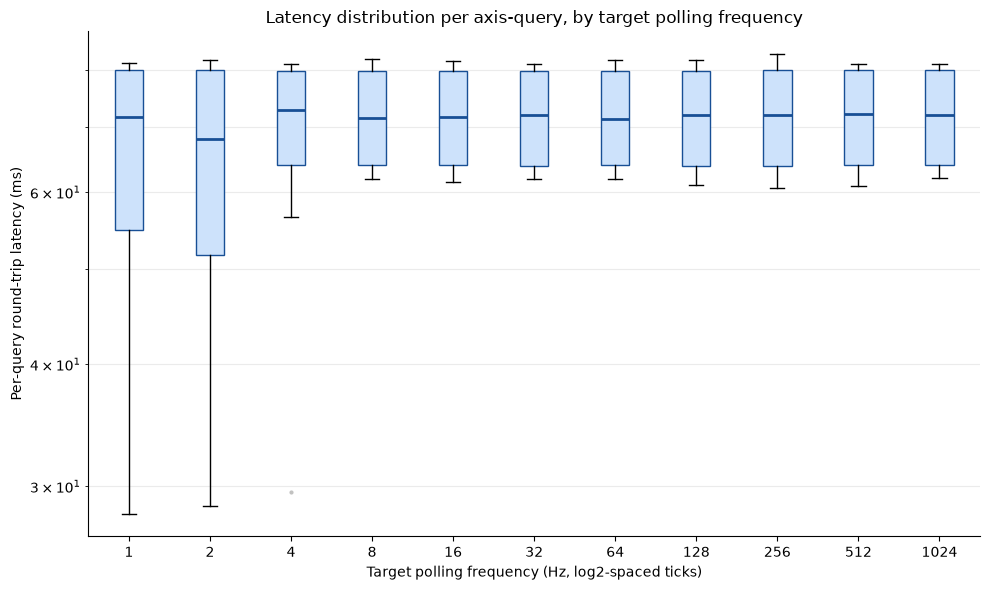

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))

target_hzs = sorted(raw["target_hz"].unique())
box_data = [raw.loc[raw["target_hz"] == hz, "latency_s"].values * 1000 for hz in target_hzs]

positions = np.log2(target_hzs)
bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.35,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=3, alpha=0.35, markerfacecolor="#52514e", markeredgecolor="none"),
)
for patch in bp["boxes"]:
    patch.set_facecolor("#cde2fb")
    patch.set_edgecolor("#184f95")
for median in bp["medians"]:
    median.set_color("#184f95")
    median.set_linewidth(2)

ax.set_xticks(positions)
ax.set_xticklabels([str(hz) for hz in target_hzs])
ax.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax.set_ylabel("Per-query round-trip latency (ms)")
ax.set_title("Latency distribution per axis-query, by target polling frequency")
ax.set_yscale("log")
ax.grid(True, which="both", axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



### Latency by axis

Splits the same latency data out per axis. This is expected to show
commander-node axes (X, Y) responding faster than responder-node axes (Z,
Theta), since the commander has to internally bridge to the second PLC node
for Z/Theta.


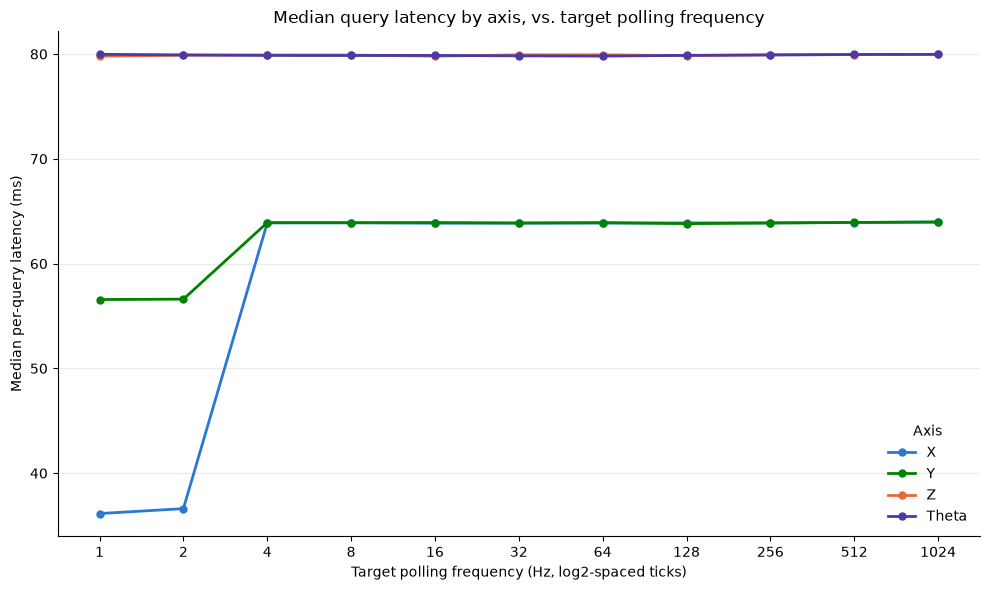

In [4]:

fig, ax = plt.subplots(figsize=(10, 6))

for axis in AXIS_ORDER:
    sub = raw[raw["axis"] == axis].groupby("target_hz")["latency_s"].median() * 1000
    ax.plot(
        np.log2(sub.index),
        sub.values,
        marker="o",
        markersize=5,
        linewidth=2,
        color=AXIS_COLORS[axis],
        label=axis,
    )

ax.set_xticks(np.log2(target_hzs))
ax.set_xticklabels([str(hz) for hz in target_hzs])
ax.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax.set_ylabel("Median per-query latency (ms)")
ax.set_title("Median query latency by axis, vs. target polling frequency")
ax.legend(title="Axis", frameon=False)
ax.grid(True, which="both", axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



## Drop rate vs. target frequency

"Drop rate" = fraction of individual axis queries that did **not** come
back as a clean `success` (i.e. timeouts + parse_errors + garbled, divided
by total axis polls) at each target frequency. This is the primary
reliability signal: as long as this stays near zero, the link is keeping up
cleanly; once it climbs, the requested rate has exceeded what the hardware
link can sustain.


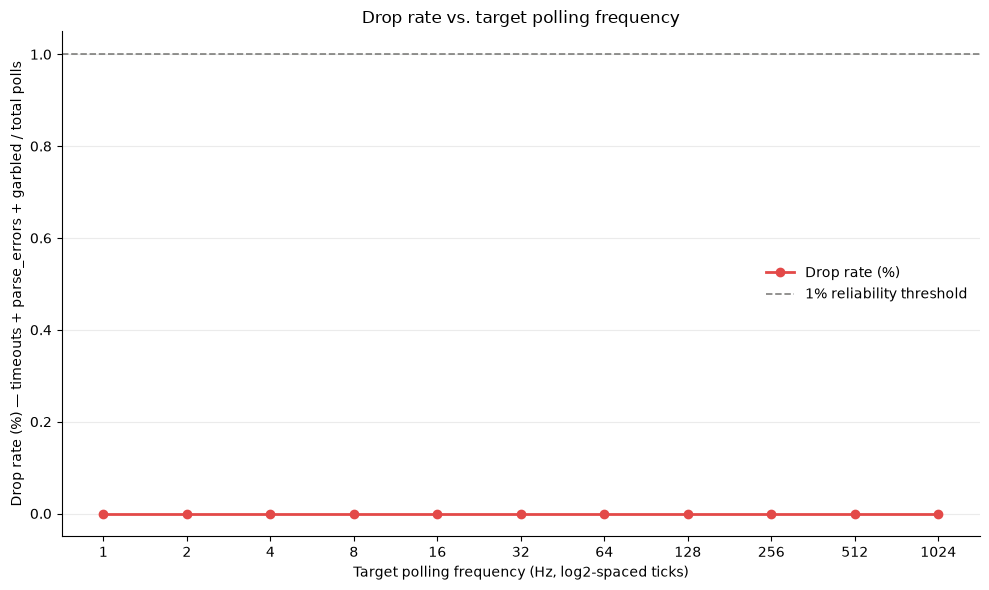

In [5]:

fig, ax1 = plt.subplots(figsize=(10, 6))

drop_pct = summary.sort_values("target_hz")["drop_rate"] * 100
hz_sorted = summary.sort_values("target_hz")["target_hz"]

ax1.plot(
    np.log2(hz_sorted),
    drop_pct,
    marker="o",
    markersize=6,
    linewidth=2,
    color="#e34948",
    label="Drop rate (%)",
)
ax1.axhline(1.0, color="#52514e", linestyle="--", linewidth=1.25, alpha=0.7,
            label="1% reliability threshold")

ax1.set_xticks(np.log2(target_hzs))
ax1.set_xticklabels([str(hz) for hz in target_hzs])
ax1.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax1.set_ylabel("Drop rate (%) — timeouts + parse_errors + garbled / total polls")
ax1.set_title("Drop rate vs. target polling frequency")
ax1.legend(frameon=False)
ax1.grid(True, which="both", axis="y", alpha=0.25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



### Breakdown of failure types

Stacked view of *why* polls failed at each frequency (timeout vs.
parse_error vs. garbled), to see whether failures at high frequencies are
simple timeouts (link too slow to respond in the window) or actual garbling
(overlapping/misframed responses — the more concerning failure mode for
data integrity).


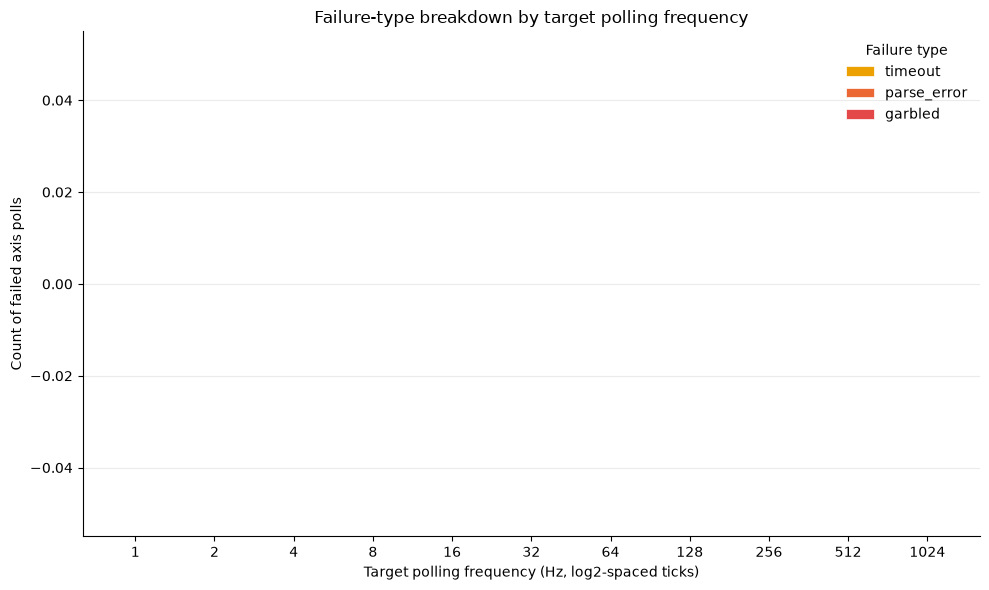

In [6]:

fig, ax = plt.subplots(figsize=(10, 6))

s = summary.sort_values("target_hz")
x = np.log2(s["target_hz"])
width = 0.3

bottom = np.zeros(len(s))
for col, color, label in [
    ("timeout_count", "#eda100", "timeout"),
    ("parse_error_count", "#eb6834", "parse_error"),
    ("garbled_count", "#e34948", "garbled"),
]:
    vals = s[col].values
    ax.bar(x, vals, width, bottom=bottom, color=color, label=label, edgecolor="white", linewidth=0.5)
    bottom += vals

ax.set_xticks(np.log2(target_hzs))
ax.set_xticklabels([str(hz) for hz in target_hzs])
ax.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax.set_ylabel("Count of failed axis polls")
ax.set_title("Failure-type breakdown by target polling frequency")
ax.legend(title="Failure type", frameon=False)
ax.grid(True, which="both", axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



## Achieved cycle rate vs. requested target rate

Each cycle (one pass over all 4 axes) has an intended target period
(`1/target_hz`) and a measured actual duration. This chart compares the
**requested** target rate against the **measured, achieved** rate
(`cycles_attempted / stage_duration_actual_s`) — the point where these two
curves diverge is where the requested polling rate first exceeds what the
hardware/link can actually sustain.


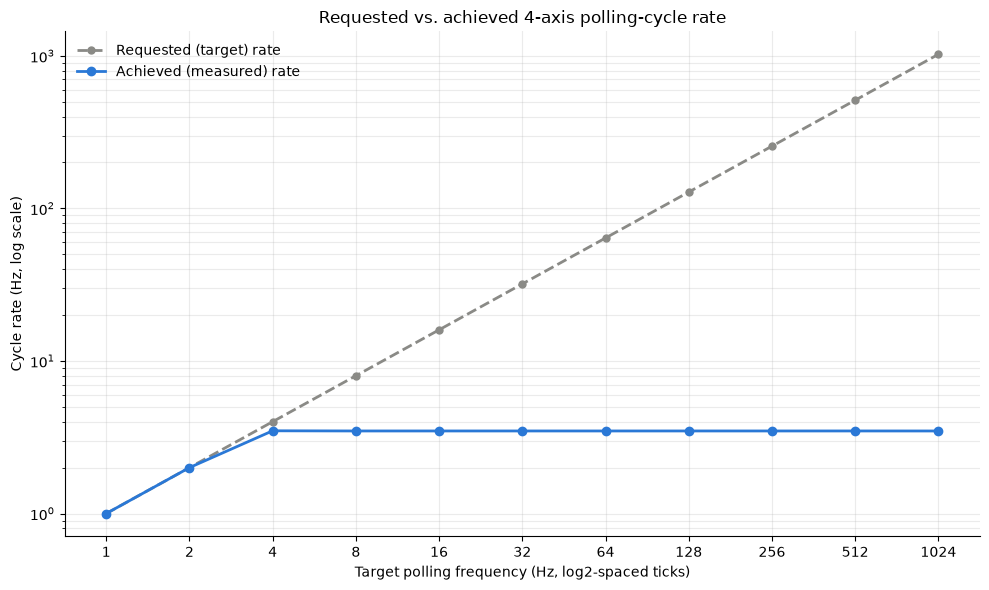

In [7]:

fig, ax = plt.subplots(figsize=(10, 6))

s = summary.sort_values("target_hz")
x = np.log2(s["target_hz"])

ax.plot(x, s["target_hz"], marker="o", markersize=5, linewidth=2,
        color="#8a8a86", linestyle="--", label="Requested (target) rate")
ax.plot(x, s["achieved_cycle_rate_hz"], marker="o", markersize=6, linewidth=2,
        color="#2a78d6", label="Achieved (measured) rate")

ax.set_xticks(np.log2(target_hzs))
ax.set_xticklabels([str(hz) for hz in target_hzs])
ax.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax.set_ylabel("Cycle rate (Hz, log scale)")
ax.set_yscale("log")
ax.set_title("Requested vs. achieved 4-axis polling-cycle rate")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



### Fraction of cycles that "kept pace"

Using the 1.5x-target-period tolerance defined above, this shows what
fraction of cycles at each target frequency were fast enough to keep up
with their intended timing.


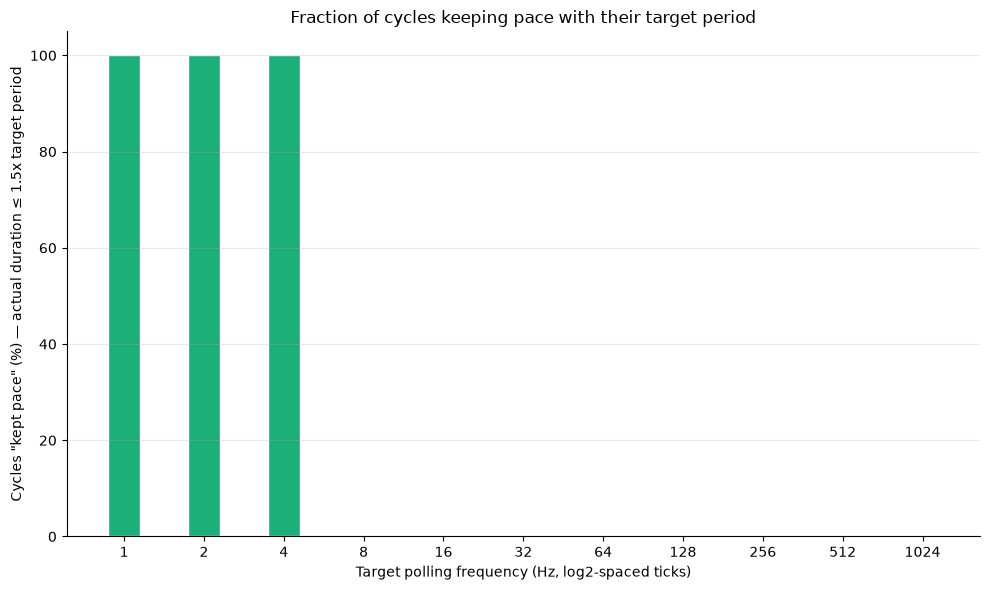

In [8]:

fig, ax = plt.subplots(figsize=(10, 6))

s = summary.sort_values("target_hz")
x = np.log2(s["target_hz"])
pace_pct = 100 * s["cycles_kept_pace"] / s["cycles_attempted"]

ax.bar(x, pace_pct, width=0.4, color="#1baf7a", edgecolor="white")
ax.set_xticks(np.log2(target_hzs))
ax.set_xticklabels([str(hz) for hz in target_hzs])
ax.set_xlabel("Target polling frequency (Hz, log2-spaced ticks)")
ax.set_ylabel('Cycles "kept pace" (%) — actual duration ≤ 1.5x target period')
ax.set_title("Fraction of cycles keeping pace with their target period")
ax.set_ylim(0, 105)
ax.grid(True, which="both", axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()



## Verdict: fastest reliable polling frequency

**Definition of "reliable" used here:** a target frequency is called
reliable if its stage's **drop rate < 1%** (fewer than 1 in 100 individual
axis queries failed as timeout/parse_error/garbled) **and** essentially all
cycles kept pace (actual cycle duration within 1.5x of the target period).
1% was chosen as a practical, conservative threshold for a position-logging
use case: a handful of missed samples out of hundreds is tolerable for
trend/logging purposes, but a link that's dropping many-percent of queries
is not a rate you'd want to run an experiment at, since it starts implying
systematic overlap/garbling rather than occasional jitter.

The cell below applies that threshold mechanically to `summary`, rather
than reading it off the charts by eye, and reports:
- the fastest **target** frequency that met the reliability bar,
- its **measured achieved** cycle rate (the real, honest number — not the
  requested one),
- the corresponding **time resolution** (seconds between reliable samples)
  = `1 / achieved_cycle_rate_hz`.


In [9]:

RELIABILITY_DROP_RATE_THRESHOLD = 0.01   # < 1%
RELIABILITY_PACE_THRESHOLD = 0.99        # >= 99% of cycles kept pace

s = summary.sort_values("target_hz").copy()
s["pace_fraction"] = s["cycles_kept_pace"] / s["cycles_attempted"]
s["is_reliable"] = (s["drop_rate"] < RELIABILITY_DROP_RATE_THRESHOLD) & (
    s["pace_fraction"] >= RELIABILITY_PACE_THRESHOLD
)

display_cols = [
    "target_hz", "drop_rate", "pace_fraction", "achieved_cycle_rate_hz",
    "median_latency_s", "p95_latency_s", "is_reliable",
]
print(s[display_cols].to_string(index=False))

reliable = s[s["is_reliable"]]
if reliable.empty:
    print("\nNo target frequency in the tested sweep met the reliability threshold.")
    print("The fastest tested frequency was", s['target_hz'].max(), "Hz; even the slowest")
    print("tested frequency (", s['target_hz'].min(), "Hz ) did not achieve a drop rate")
    print("below", RELIABILITY_DROP_RATE_THRESHOLD, "and/or did not keep pace on",
          RELIABILITY_PACE_THRESHOLD * 100, "% of cycles -- see the table above for the")
    print("actual numbers driving that conclusion.")
else:
    best = reliable.sort_values("target_hz", ascending=False).iloc[0]
    achieved_rate = best["achieved_cycle_rate_hz"]
    resolution_s = 1.0 / achieved_rate
    print(f"\nFastest reliable TARGET frequency: {best['target_hz']:.0f} Hz")
    print(f"  drop rate:            {best['drop_rate']*100:.3f}%")
    print(f"  cycles kept pace:     {best['pace_fraction']*100:.1f}%")
    print(f"  ACHIEVED cycle rate:  {achieved_rate:.3f} Hz  (measured, not requested)")
    print(f"  time resolution:      {resolution_s*1000:.1f} ms between reliable samples")


 target_hz  drop_rate  pace_fraction  achieved_cycle_rate_hz  median_latency_s  p95_latency_s  is_reliable
         1        0.0            1.0                0.999994          0.071692       0.080969         True
         2        0.0            1.0                1.999989          0.068008       0.080928         True
         4        0.0            1.0                3.486323          0.072793       0.080922         True
         8        0.0            0.0                3.477089          0.071435       0.080989        False
        16        0.0            0.0                3.477297          0.071546       0.080978        False
        32        0.0            0.0                3.477345          0.071885       0.080927        False
        64        0.0            0.0                3.476964          0.071281       0.080983        False
       128        0.0            0.0                3.477568          0.071886       0.081032        False
       256        0.0            0.0 


## Caveats / how to read these numbers

- This measures **one specific link** (this PC → SSH-managed TCP bridge on
  the Pi → RS232 9600 8N1 → OEM-2T controller), at its currently configured
  baud rate. It is not a measurement of the controller's theoretical
  maximum, nor of what a different baud rate or a persistent SSH+JSON
  transport (`PiGantryConnection`, see `docs/MACRON_GANTRY.md`) might
  achieve.
- Because queries are strictly serial (one command fully round-trips
  before the next is sent — see `benchmark_polling.py`), the "achieved
  cycle rate" is fundamentally capped by the sum of the 4 axes' real
  round-trip latencies; it cannot exceed roughly
  `1 / (mean 4-axis cycle latency)` regardless of how high the *target*
  frequency is set. That ceiling is exactly what the "requested vs.
  achieved" chart above visualizes.
- No motion was ever commanded to the hardware in the course of this test —
  every query sent was one of the four read-only `ACP` queries listed in
  the safety-constraint section above.
